# Mock Spectra Cross Correlation Tests

In this code, I create mock spectra from scratch and run cross correlation experiments

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.path import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import PathPatch, Rectangle
from scipy.spatial import cKDTree
from scipy.interpolate import interp1d
from pyhdf.SD import SD, SDC
from matplotlib.widgets import Button


from scipy.signal import correlate, find_peaks, savgol_filter, peak_widths
from scipy import signal


%matplotlib widget

In [21]:
def normalize_spectrum(spectrum, eps=1e-30):
    s0 = spectrum - np.mean(spectrum)
    n0 = np.linalg.norm(s0)
    if n0 < eps:
        return np.zeros_like(spectrum)
    return s0 / n0

# def add_poisson_noise_snr(T, snr):
#     noise = np.random.normal(0, 1/snr, size=T.shape) #Mean = 0, Standard Deviation = 1/SNR, Normal indicates gaussian distribution, size=T.shape ensures noise array matches T array in size
#     return T + noise

def fake_family_spectrum(
    molecule_names, dwn, wn_min, wn_max,
    base_centers, shifts,
    width, jitter=0.02, depth_scale=1.0,
    seed=None
):
    rng = np.random.default_rng(seed)
    wn = np.arange(wn_min, wn_max, dwn)

    # shared line pattern
    center_jitter = rng.normal(0, jitter, size=len(base_centers))
    depths = depth_scale * rng.uniform(0.02, 0.08, size=len(base_centers))

    # build template at shift = 0
    T0 = np.ones_like(wn, dtype=float)
    for j, c in enumerate(base_centers):
        c0 = c + center_jitter[j]
        T0 -= depths[j] * np.exp(-(wn - c0)**2 / (2 * width**2))

    spectra = {}
    for mol in molecule_names:
        s = shifts[mol]
        # Evaluate template at (wn - s): this shifts features to the right by +s
        T_shift = np.interp(wn, wn + s, T0, left=1.0, right=1.0)

        spec_res = np.median(wn) / dwn

        spectra[mol] = {
            "wavenumber": wn,
            "transmission": T_shift,
            "shift": s,
            "spec_res": f"{spec_res:.0e}",
            "base_centers": base_centers
        }
    return spectra

def add_poisson_noise_photon(T, snr_cont, seed=None):
    T = np.asarray(T, dtype=float)
    rng = np.random.default_rng(seed)

    N0 = float(snr_cont)**2
    if N0 <= 0:
        raise ValueError("snr_cont must be > 0")

    # Noisy continuum counts per bin
    I0 = rng.poisson(N0, size=T.shape)

    # Prevent divide-by-zero (Poisson(1) gives zeros often!)
    I0 = np.maximum(I0, 1)

    # Noisy transmitted counts
    lam = np.clip(N0 * T, 0.0, np.inf)
    I  = rng.poisson(lam)

    T_noisy = I / I0
    return T_noisy


def noisify(
    T, snr_list:list, seed_base=0, return_absorbance=True
):
    """
    T: noiseless transmittance spectrum
    snr_list: list of continuum SNR values
    return_absorbance: if True, also return absorbance
    """
    noisy = {}

    for i, snr in enumerate(snr_list):
        T_noisy = add_poisson_noise_photon(T, snr_cont=snr, seed=seed_base+i)

        if return_absorbance:
            A_noisy = -np.log(np.clip(T_noisy, 1e-12, None))
            noisy[snr] = {"T": T_noisy, "A": A_noisy}
        else:
            noisy[snr] = {"T": T_noisy}

    return noisy

#Extract the one sigma uncertainty from spectra:
def poisson_sigma_T_from_model(T, snr_cont):
    N0 = snr_cont**2
    return np.sqrt(np.clip(T, 0, None) / N0)

def mix_spectra_by_weights(spectra, weights, domain="absorbance"):
    """
    spectra: dict like spectra[mol] = {"wavenumber": wn, "transmission": T, ...}
            (all molecules must share the same wn grid)
    weights: dict mol -> weight (doesn't have to sum to 1; we will normalize)
    domain: "absorbance" (recommended) or "transmittance" (not recommended)
    returns: wn, T_mix, A_mix
    """
    mols = list(weights.keys())

    # check common grid
    wn0 = np.asarray(spectra[mols[0]]["wavenumber"])
    for m in mols[1:]:
        if len(spectra[m]["wavenumber"]) != len(wn0) or not np.allclose(spectra[m]["wavenumber"], wn0):
            raise ValueError("All molecules must be on the same wavenumber grid to mix directly.")

    # normalize weights to sum to 1 (optional but nice)
    w = np.array([weights[m] for m in mols], dtype=float)
    wsum = w.sum()
    if wsum <= 0:
        raise ValueError("Weights must sum to a positive number.")
    w = w / wsum

    if domain == "absorbance":
        A_mix = np.zeros_like(wn0, dtype=float)
        for wi, m in zip(w, mols):
            T = np.asarray(spectra[m]["transmission"], dtype=float)
            A = -np.log(np.clip(T, 1e-12, None))
            A_mix += wi * A
        T_mix = np.exp(-A_mix)
        return wn0, T_mix, A_mix

    elif domain == "transmittance":
        # Not physically ideal; included only if you explicitly want it.
        T_mix = np.zeros_like(wn0, dtype=float)
        for wi, m in zip(w, mols):
            T_mix += wi * np.asarray(spectra[m]["transmission"], dtype=float)
        A_mix = -np.log(np.clip(T_mix, 1e-12, None))
        return wn0, T_mix, A_mix

    else:
        raise ValueError("domain must be 'absorbance' or 'transmittance'")


# Creating fake family spectra

In [22]:
base_centers = np.linspace(2900, 3000, 200)

wn_min = 2900
wn_max = 3000
test_dwns = [1, 0.5, 0.1, 0.01, 0.001, 0.0001]
wn = np.linspace(wn_min, wn_max, 100000)
width = 0.1

shifts = {
    'Molecule 1': 0.0,
    'Molecule 2': 1.2,
    'Molecule 3': -2.1,
    'Molecule 4': np.random.uniform(-5, 5),
    'Molecule 5': np.random.uniform(-5, 5),
    'Molecule 6': np.random.uniform(-5, 5),
    'Molecule 7': np.random.uniform(-5, 5),
    'Molecule 8': np.random.uniform(-5, 5),
    'Molecule 9': np.random.uniform(-5, 5),
    'Molecule 10': np.random.uniform(-5, 5)
}

parent_spectra = {}

molecule_names = list(shifts.keys())

for dwn in test_dwns:
    spectra = fake_family_spectrum(
        molecule_names, dwn=dwn, wn_min=2800, wn_max=3200,
        base_centers=base_centers, shifts=shifts,
        width=width, jitter=0.02, depth_scale=1.0,
        seed=42
    )
    parent_spectra[f'spec_res_{spectra["Molecule 1"]["spec_res"]}'] = spectra


# Creating summed spectra

In [23]:
even = 1/10
weights = {
    'Molecule 1': even,
    'Molecule 2': even,
    'Molecule 3': even,
    'Molecule 4': even,
    'Molecule 5': even,
    'Molecule 6': even,
    'Molecule 7': even,
    'Molecule 8': even,
    'Molecule 9': even,
    'Molecule 10': even
    }

mixed_spectra = {}

for res_key, spectra in parent_spectra.items():
    wn, T_mix, A_mix = mix_spectra_by_weights(spectra, weights, domain="absorbance")
    mixed_spectra[res_key] = {
        "wavenumber": wn,
        "transmission": T_mix,
        "absorbance": A_mix
    }

In [24]:
print(parent_spectra['spec_res_3e+03'].keys())

dict_keys(['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10'])


# Incorporate noise

In [25]:
for res_key, spectra in parent_spectra.items():
    print(list(spectra.keys()))

['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']
['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']
['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']
['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']
['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']
['Molecule 1', 'Molecule 2', 'Molecule 3', 'Molecule 4', 'Molecule 5', 'Molecule 6', 'Molecule 7', 'Molecule 8', 'Molecule 9', 'Molecule 10']


In [26]:
snr_list = [1, 3, 5, 10, 50, 1000]

# Parent spectra

for res_key, spectra in parent_spectra.items():
    molecule_names = list(spectra.keys())
    for mol in molecule_names:
        T = parent_spectra[res_key][mol]["transmission"]

        noisy_dict = noisify(T, snr_list, seed_base=100)

        for snr in snr_list:
            parent_spectra[res_key][mol][f"T_noisy_{snr}"] = noisy_dict[snr]["T"]
            parent_spectra[res_key][mol][f"A_noisy_{snr}"] = noisy_dict[snr]["A"]

# Mixed spectra

for res_key, mix_spec in mixed_spectra.items():
    T = mix_spec["transmission"]

    noisy_dict = noisify(T, snr_list, seed_base=200)

    for snr in snr_list:
        mixed_spectra[res_key][f"T_noisy_{snr}"] = noisy_dict[snr]["T"]
        mixed_spectra[res_key][f"A_noisy_{snr}"] = noisy_dict[snr]["A"]

# Cross Correlation

In [27]:
cc_results = []

for res_key, spectra in parent_spectra.items():

    wn = spectra[molecule_names[0]]["wavenumber"]
    dwn = np.median(np.diff(wn))

    for snr in snr_list:

        A_sum = mixed_spectra[res_key][f"A_noisy_{snr}"]
        A_sum_n = normalize_spectrum(A_sum)

        max_shift_cm1 = 3.0
        max_shift_bins = int(np.ceil(max_shift_cm1 / dwn))

        for mol in molecule_names:

            A_m = spectra[mol][f"A_noisy_{snr}"]
            A_m_n = normalize_spectrum(A_m)

            cc = correlate(A_sum_n, A_m_n, mode="full")
            lags = signal.correlation_lags(len(A_sum_n), len(A_m_n), mode="full")

            mask = np.abs(lags) <= max_shift_bins
            peak = np.max(cc[mask])
            lag_best = lags[mask][np.argmax(cc[mask])]
            shift_cm1 = lag_best * dwn

            cc_snr = peak / (np.std(cc[mask]) + 1e-30)

            cc_results.append({
                "resolution": res_key,
                "snr": snr,
                "molecule": mol,
                "cc_peak": peak,
                "cc_snr": cc_snr,
                "best_shift_cm1": shift_cm1
            })


In [28]:
df = pd.DataFrame(cc_results)
df

,resolution,snr,molecule,cc_peak,cc_snr,best_shift_cm1
0,spec_res_3e+03,1,Molecule 1,0.066487,1.466170,0.0000
1,spec_res_3e+03,1,Molecule 2,0.055853,1.755158,-1.0000
2,spec_res_3e+03,1,Molecule 3,0.066091,1.685270,-1.0000
3,spec_res_3e+03,1,Molecule 4,0.066487,1.466170,0.0000
4,spec_res_3e+03,1,Molecule 5,0.059386,1.541191,0.0000
...,...,...,...,...,...,...
355,spec_res_3e+07,1000,Molecule 6,0.759651,23.203973,1.8455
356,spec_res_3e+07,1000,Molecule 7,0.770356,25.028533,2.8730
357,spec_res_3e+07,1000,Molecule 8,0.770540,26.385508,2.5973
358,spec_res_3e+07,1000,Molecule 9,0.758691,21.365340,-0.5736


In [29]:
cross_correlation_results = df.pivot_table(index = ["resolution", "snr"], columns="molecule", values=["cc_snr", "cc_peak"])

In [30]:
cross_correlation_results

cc_peak                                               \
molecule            Molecule 1 Molecule 10 Molecule 2 Molecule 3 Molecule 4   
resolution     snr                                                            
spec_res_3e+03 1      0.066487    0.055853   0.055853   0.066091   0.066487   
               3      0.054833    0.053924   0.056661   0.063537   0.054361   
               5      0.082197    0.118033   0.115159   0.125289   0.115568   
               10     0.106453    0.051457   0.051405   0.064997   0.100248   
               50     0.201666    0.203933   0.226100   0.194764   0.202581   
               1000   0.912386    0.919927   0.930910   0.926312   0.947244   
spec_res_3e+04 1      0.028177    0.033395   0.027941   0.041883   0.045734   
               3      0.035097    0.037740   0.039263   0.029008   0.039656   
               5      0.038234    0.042087   0.036541   0.034336   0.035464   
               10     0.040612    0.054285   0.040073   0.035436   0.043450   
               50     0.163342    0.163736   0.166429   0.162800   0.165045   
               1000   0.777418    0.798566   0.779033   0.765205   0.822039   
spec_res_3e+05 1      0.015269    0.012647   0.015366   0.016936   0.013330   
               3      0.051409    0.047546   0.049225   0.048542   0.052214   
               5      0.014890    0.017367   0.014645   0.018884   0.018193   
               10     0.024693    0.020328   0.027511   0.020054   0.023361   
               50     0.141007    0.138169   0.139942   0.137618   0.138888   
               1000   0.788501    0.789247   0.788890   0.771293   0.789436   
spec_res_3e+06 1      0.005240    0.007277   0.006324   0.005451   0.005441   
               3      0.009439    0.009945   0.007494   0.007393   0.009143   
               5      0.007298    0.008256   0.007445   0.007491   0.007519   
               10     0.011963    0.011493   0.010966   0.011662   0.011045   
               50     0.136433    0.136621   0.137966   0.133589   0.137370   
               1000   0.787999    0.788653   0.788724   0.770929   0.788489   
spec_res_3e+07 1      0.002105    0.002137   0.002298   0.002251   0.002082   
               3      0.002743    0.002632   0.002535   0.002771   0.002825   
               5      0.003588    0.003770   0.003643   0.003758   0.003814   
               10     0.008007    0.008173   0.008387   0.008107   0.008057   
               50     0.135309    0.135426   0.135300   0.132319   0.135768   
               1000   0.787839    0.788530   0.788497   0.770808   0.788370   
spec_res_6e+03 1      0.053774    0.061545   0.061545   0.072115   0.061545   
               3      0.045471    0.044198   0.059748   0.043671   0.059132   
               5      0.055495    0.058170   0.041774   0.048641   0.069229   
               10     0.074263    0.070350   0.087909   0.085246   0.069535   
               50     0.264621    0.241411   0.266429   0.282751   0.263016   
               1000   0.900283    0.922067   0.936720   0.919263   0.916050   

                                                                            \
molecule            Molecule 5 Molecule 6 Molecule 7 Molecule 8 Molecule 9   
resolution     snr                                                           
spec_res_3e+03 1      0.059386   0.055838   0.066091   0.066091   0.059386   
               3      0.048972   0.057142   0.049937   0.056275   0.050873   
               5      0.076919   0.121704   0.151999   0.076798   0.075356   
               10     0.057975   0.053450   0.047191   0.065302   0.071726   
               50     0.231785   0.190588   0.184145   0.189472   0.236676   
               1000   0.926590   0.915268   0.933232   0.950154   0.917459   
spec_res_3e+04 1      0.036515   0.042683   0.043459   0.037727   0.033175   
               3      0.038650   0.034326   0.029024   0.048056   0.036807   
               5      0.043225   0.038834   0.032147   0.037790   0.049956   
     

In [31]:
wavenumber_bins_for_loop = [1, 0.1, 0.01, 0.001]
snr_to_test = [1,3,5,10,50, 1000]
molecule_weights = {
    'Molecule 1': 0.33,
    'Molecule 2': 0.33,
    'Molecule 3': 0.33
}

summed_spectra = {}
results = []

for i in range(len(wavenumber_bins_for_loop)):

    #Creating Summed Spectrum______________________________________________________________________________________________________________________________

    bin_width = wavenumber_bins_for_loop[i]             # bin width in cm^-1

    # === OUTPUT ARRAYS ===
    bin_edges = np.arange(wn_min, wn_max + bin_width, bin_width)

    molecules = list(molecule_weights.keys())
    weights = list(molecule_weights.values())

    resolution_median_by_molecule = {}

    binned_abs_sum = np.zeros(len(bin_edges) - 1)

    # bin + sum across molecules in absorbance space
    for molecule in molecules:
        weight = molecule_weights[molecule]
        T = spectra[molecule]['transmission']
        wn_array = np.asarray(spectra[molecule]['wavenumber'])

        A = -np.log(np.clip(T, 1e-12, None)) * weight

        sumw, _ = np.histogram(wn_array, bins=bin_edges, weights=A)
        cnt,  _ = np.histogram(wn_array, bins=bin_edges)
        A_binned = sumw / np.clip(cnt, 1, None)

        binned_abs_sum += A_binned

        #compute median resolution for each molecule
        dwns = np.diff(wn_array)
        resolution_by_molecule = wn_array[:-1] / dwns
        median_resolution = np.median(resolution_by_molecule)
        resolution_median_by_molecule[molecule] = median_resolution

    # convert mixture back to transmittance before adding transmittance noise
    T_sum = np.exp(-binned_abs_sum)

    for snr in snr_to_test:
        T_sum_noisy = add_poisson_noise_photon(T_sum, snr, 42)
        A_sum_noisy = -np.log(np.clip(T_sum_noisy, 1e-12, None))

        # make noisy molecule spectra in same domain (absorbance here)
        for molecule in molecules:
            T_m = spectra[molecule]['transmission']
            T_m_noisy = add_poisson_noise_photon(T_m, snr, 42)
            A_m_noisy = -np.log(np.clip(T_m_noisy, 1e-12, None))
            spectra[molecule][f'A_noisy_{snr}'] = A_m_noisy


        max_shift_cm1 = 2
        max_shift_summed = int(max_shift_cm1/ bin_width)  # maximum shift, physically motivated

        for molecule in molecules:
            weight = molecule_weights[molecule]
            cross_correlation_vector_summed = correlate(A_sum_noisy, normalize_spectrum(spectra[molecule][f'A_noisy_{snr}']), mode='full')    
            lags_summed = signal.correlation_lags(len(A_sum_noisy), len(spectra[molecule][f'A_noisy_{snr}']), mode='full')
            lag_0_summed = len(A_sum_noisy) - 1

            mask_summed = np.abs(lags_summed) <= max_shift_summed  
            similarity_summed = np.max(cross_correlation_vector_summed[mask_summed])
            spectra[molecule][f'similarity_summed_noisy_snr_{snr}'] = similarity_summed
            spectra[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'] = cross_correlation_vector_summed
            spectra[molecule][f'lags_summed_snr_{snr}'] = lags_summed
            spectra[molecule][f'SNR_summed_noisy_snr_{snr}'] = similarity_summed / np.std(spectra[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'][mask_summed])

            summed_spectra[f'summed_spectrum_noisy_normalized_{snr}'] = A_sum_noisy / np.linalg.norm(A_sum_noisy)

            results.append({
                'molecule': molecule,
                'wavenumber_bin': bin_width,
                'Resolution' : resolution_median_by_molecule[molecule],
                'weight': weight,
                'input snr': snr,
                'similarity_summed_noisy': similarity_summed,
                'similarity_snr': spectra[molecule][f'SNR_summed_noisy_snr_{snr}']
            })

                

            # print(f'{molecule} Similarity (summed noisy SNR={snr}, weight={weight}): ', similarity_summed, "SNR: ", spectra[molecule][f'SNR_summed_noisy_snr_{snr}'])


# Plots

/Users/zaniaccollins/Desktop/SGL/Python/.venv/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


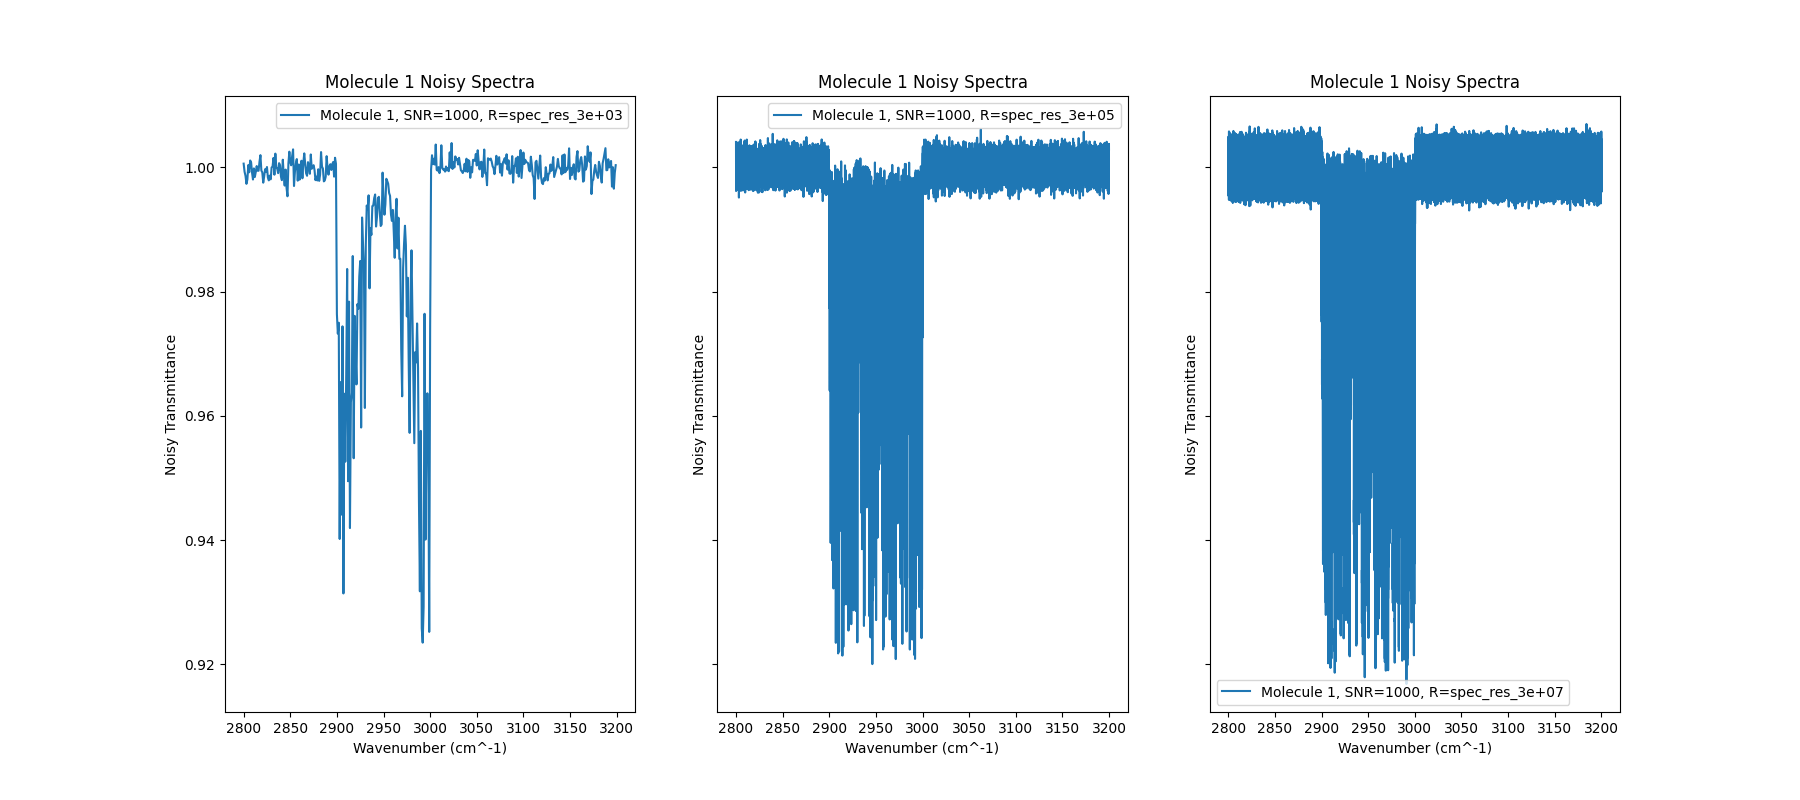

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True, sharey=True)
ax = axes.flatten()

snr_to_plot = 1000
res_to_plot = ['spec_res_3e+03', 'spec_res_3e+05', 'spec_res_3e+07']

for res in res_to_plot:
    ax_index = res_to_plot.index(res)
    ax[ax_index].plot(parent_spectra[res]['Molecule 1']['wavenumber'], parent_spectra[res]['Molecule 1'][f'T_noisy_{snr_to_plot}'], label=f'Molecule 1, SNR={snr_to_plot}, R={res}')
    ax[ax_index].set_title(f'Molecule 1 Noisy Spectra')
    ax[ax_index].set_xlabel('Wavenumber (cm^-1)')
    ax[ax_index].set_ylabel('Noisy Transmittance')
    ax[ax_index].legend()



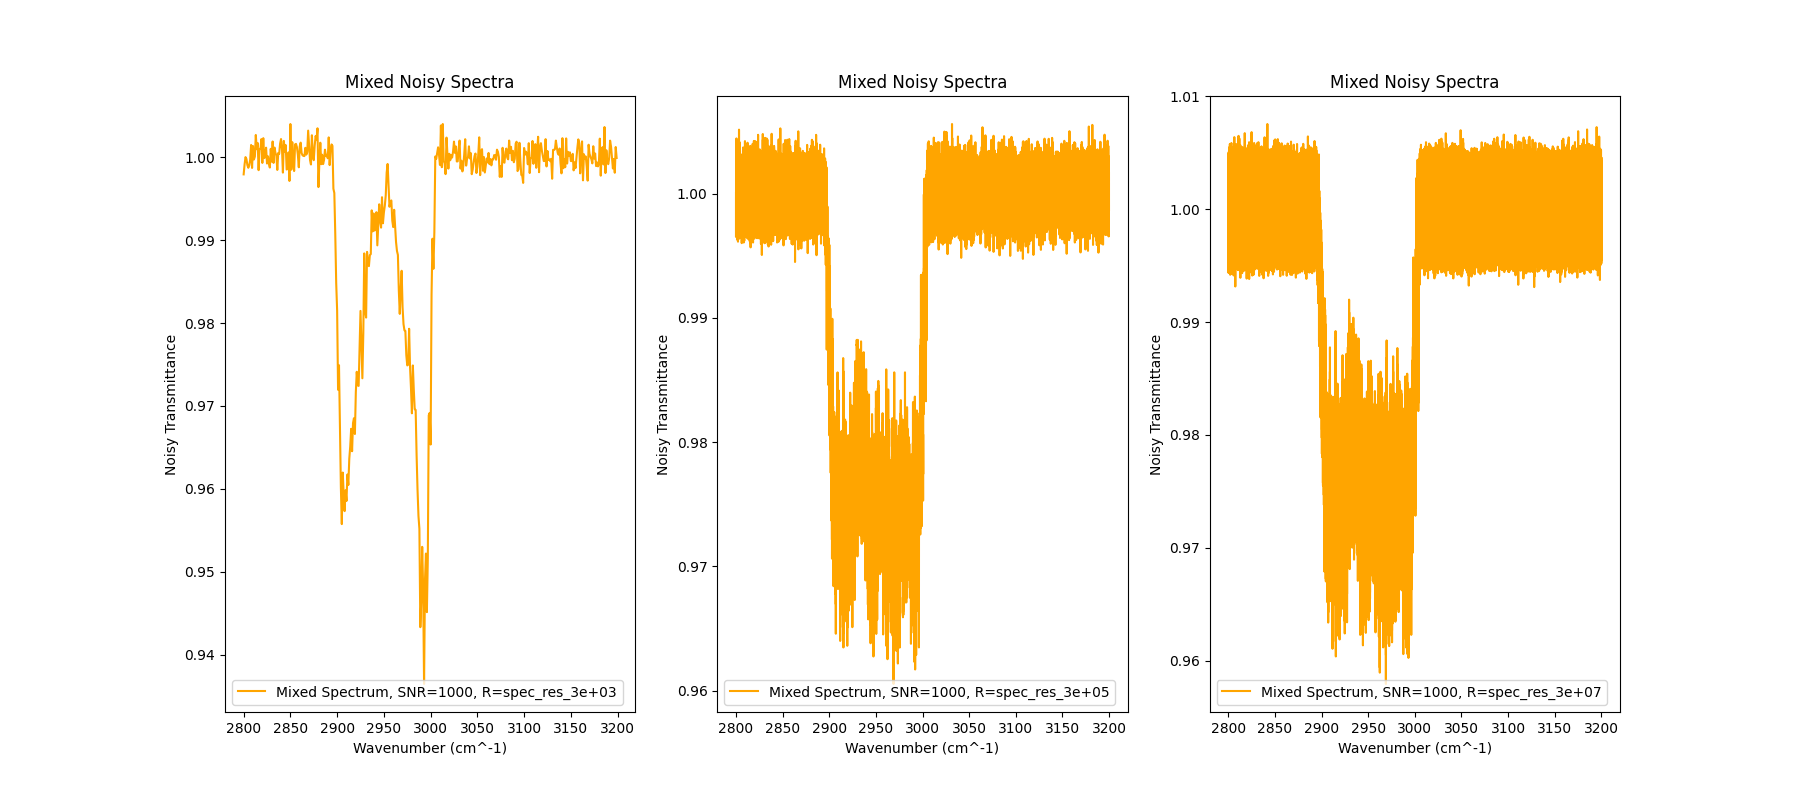

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
ax = axes.flatten()

for res in res_to_plot:
    ax_index = res_to_plot.index(res)
    ax[ax_index].plot(mixed_spectra[res]['wavenumber'], mixed_spectra[res][f'T_noisy_{snr_to_plot}'], label=f'Mixed Spectrum, SNR={snr_to_plot}, R={res}', color='orange')
    ax[ax_index].set_title(f'Mixed Noisy Spectra')
    ax[ax_index].set_xlabel('Wavenumber (cm^-1)')
    ax[ax_index].set_ylabel('Noisy Transmittance')
    ax[ax_index].legend()

## Plotting with error bars

In [34]:
errors = {}

for noise in snr_list:
    stdev = []
    for spec_res, spectra in parent_spectra.items():
        for mol in molecule_names:
            T_noisy = parent_spectra[spec_res][mol][f"T_noisy_{noise}"]
            sigma_T = poisson_sigma_T_from_model(T_noisy, snr_cont=noise)
            errors[spec_res, mol, noise] = sigma_T
            

/var/folders/0y/zn1dltkd6hj_8m8pq81r_98r0000gn/T/ipykernel_10467/2812729999.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/zaniaccollins/Desktop/SGL/Python/.venv/lib/python3.11/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


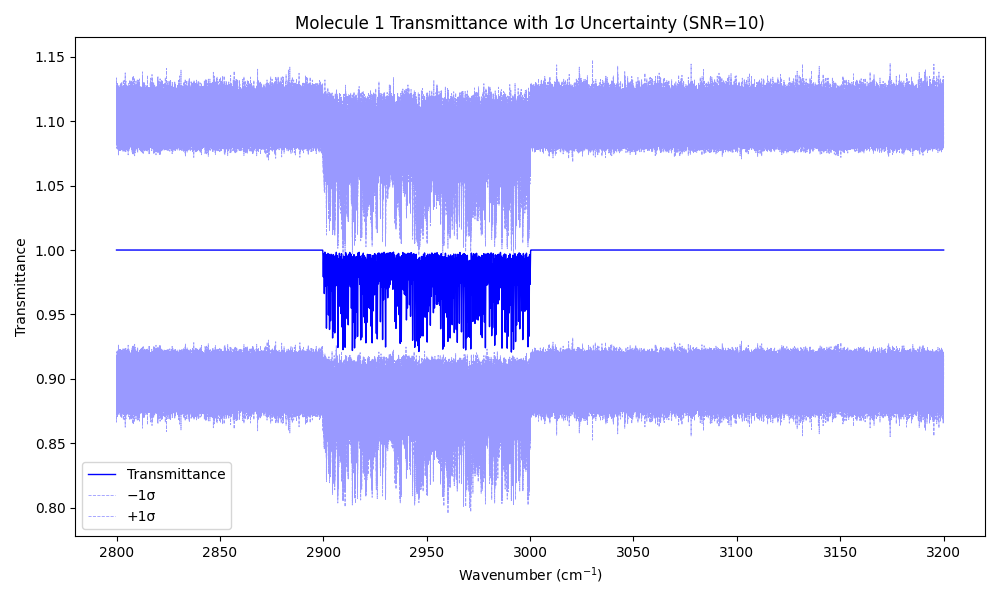

In [36]:
x = parent_spectra['spec_res_3e+07']['Molecule 1']['wavenumber']
y = parent_spectra['spec_res_3e+07']['Molecule 1']['transmission']
e = errors['spec_res_3e+07', 'Molecule 1', 10]

plt.figure(figsize=(10, 6))

# central spectrum
plt.plot(x, y, color='blue', linewidth=1.0, label='Transmittance')

# ±1σ bounds as lines
plt.plot(x, y - e, color='blue', linewidth=0.6, alpha=0.4, linestyle='--', label='−1σ')
plt.plot(x, y + e, color='blue', linewidth=0.6, alpha=0.4, linestyle='--', label='+1σ')

plt.title('Molecule 1 Transmittance with 1σ Uncertainty (SNR=10)')
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Transmittance')
plt.legend()
plt.tight_layout()
plt.show()
